In [2]:
#instalo biblioteca

!pip install opencv-python

import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import cv2 as cv
from pathlib import Path
import math


print("Python:", __import__("sys").executable)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("OpenCV:", cv.__version__)




Python: /home/diego/anaconda3/bin/python
NumPy: 2.5.3
Matplotlib: 3.11.2
OpenCV: 5.0.0


In [3]:
path="./white_patch/"

# Primer parte

Cargo las imaganes para wp

In [4]:
directorio = Path(path)

imagenes = {}

for archivo in directorio.iterdir():
    if archivo.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:

        img = cv.imread(str(archivo), cv.IMREAD_COLOR)

        if img is not None:
            imagenes[archivo.name] = img

print(f"Imágenes cargadas: {len(imagenes)}")

Imágenes cargadas: 8


algoritmo de white patch


In [5]:
import numpy as np

def ejecutar_wp(image):
    image = image.astype(np.float32)

    R = image[:, :, 0]
    G = image[:, :, 1]
    B = image[:, :, 2]

    R_max = R.max()
    G_max = G.max()
    B_max = B.max()

    R_norm = R * 255 / R_max if R_max > 0 else R
    G_norm = G * 255 / G_max if G_max > 0 else G
    B_norm = B * 255 / B_max if B_max > 0 else B

    return np.stack([R_norm, G_norm, B_norm], axis=2).astype(np.uint8)

reviso lo que levanto



wp_red2.jpg - Tamaño: (1600, 1200, 3)
wp_blue.jpg - Tamaño: (1600, 1200, 3)
wp_red.png - Tamaño: (813, 481, 3)
wp_green2.jpg - Tamaño: (1600, 1200, 3)
wp_green.png - Tamaño: (571, 363, 3)
test_green.png - Tamaño: (100, 278, 3)
test_red.png - Tamaño: (99, 276, 3)
test_blue.png - Tamaño: (100, 278, 3)


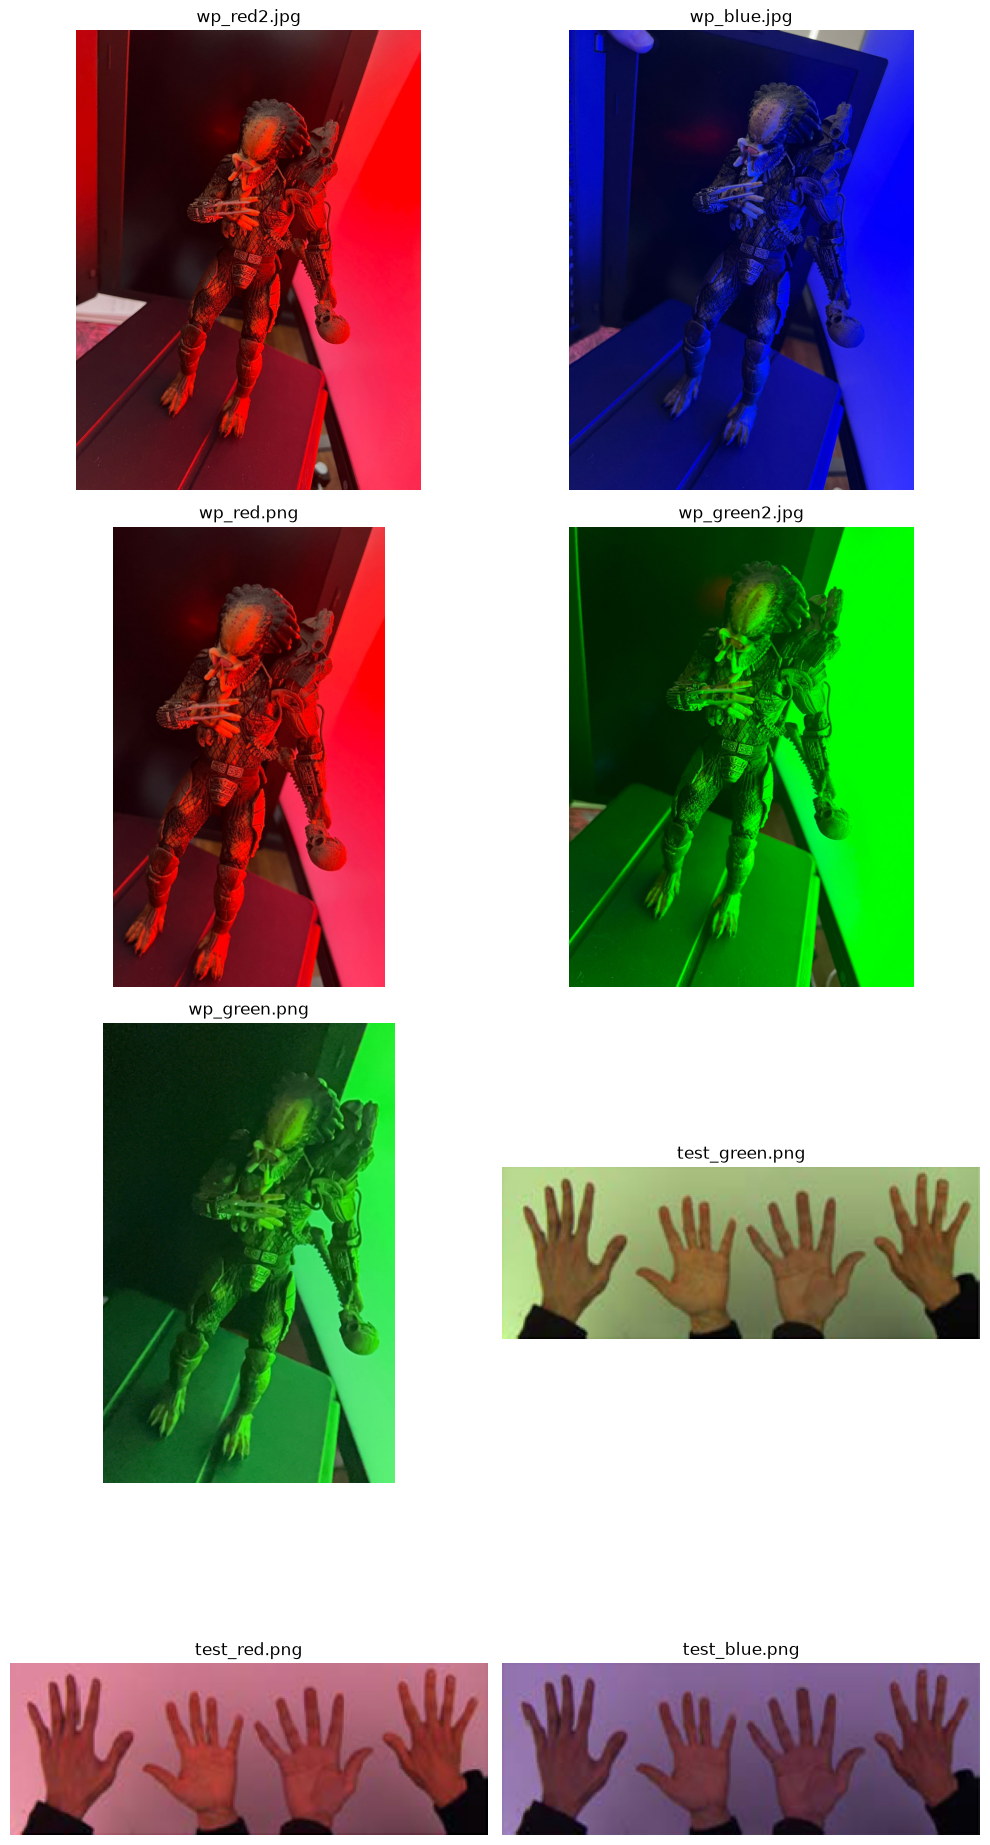

In [6]:
n = len(imagenes)

# 2 columnas
columnas = 2
filas = math.ceil(n / columnas)

fig = plt.figure(figsize=(10, 5 * filas))

for i, (nombre, img) in enumerate(imagenes.items()):

    # BGR -> RGB
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    print(f"{nombre} - Tamaño: {img.shape}")

    # Subplot: filas x columnas
    ax = plt.subplot(filas, columnas, i + 1)

    ax.imshow(img_rgb)
    ax.set_title(nombre)
    ax.axis("off")

plt.tight_layout()
plt.show()

Aplica el metodo de wp

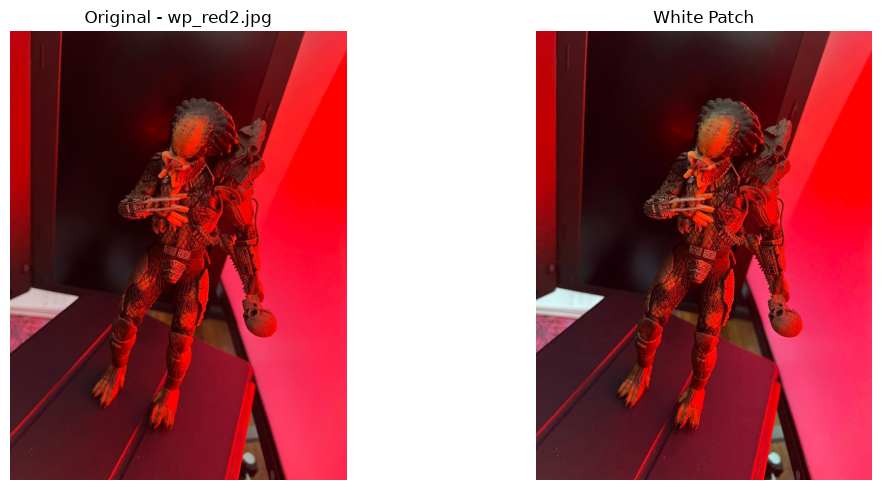

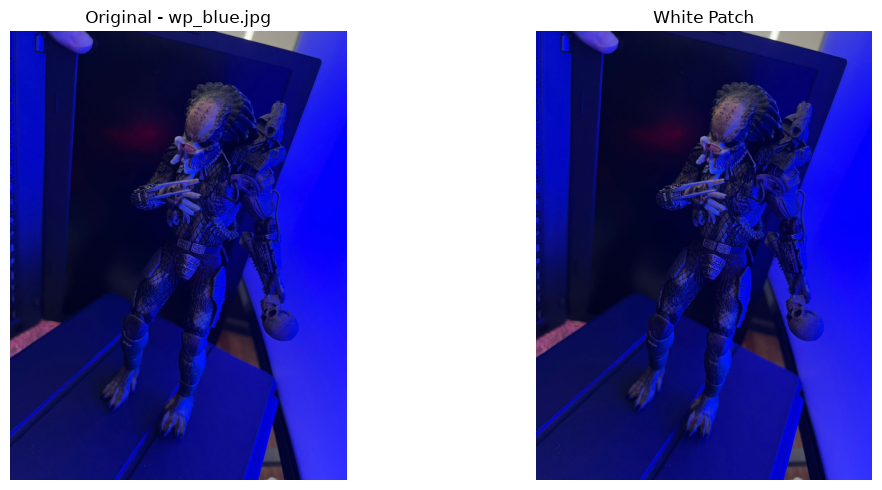

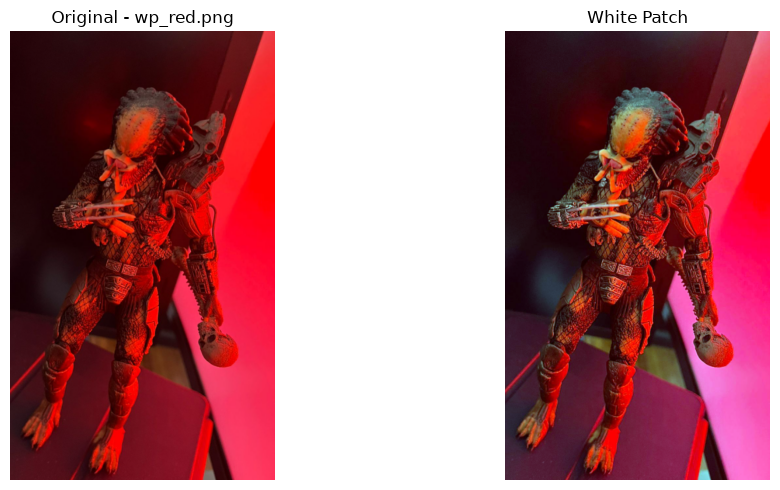

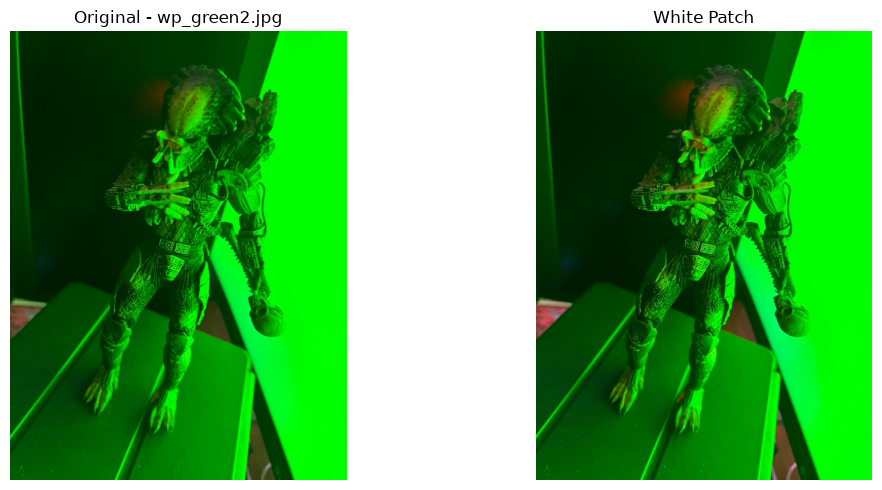

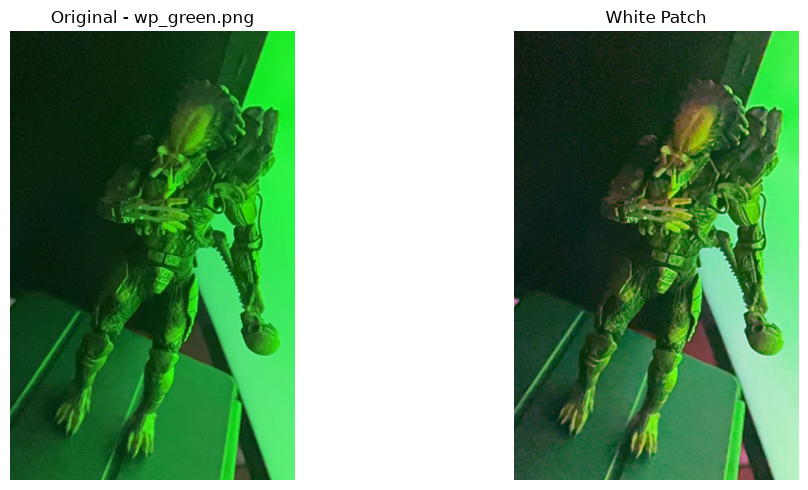

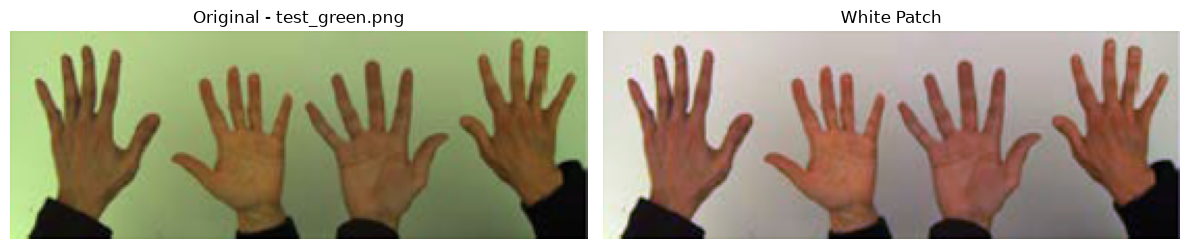

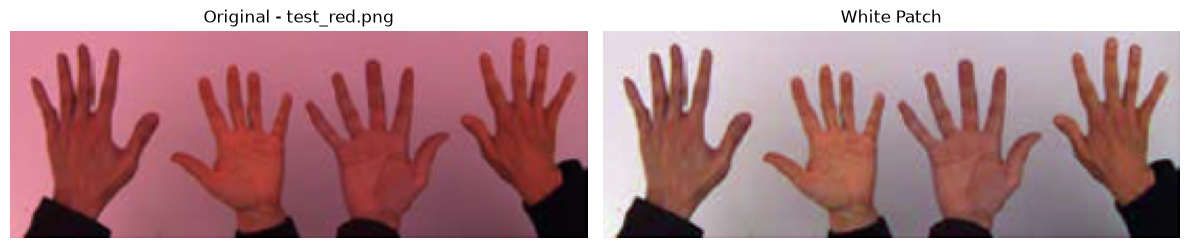

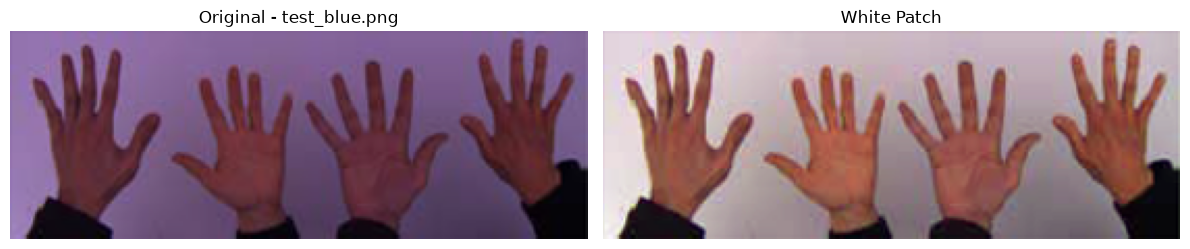

In [7]:
for nombre, img in imagenes.items():

    # Ejecutar White Patch
    img_wp = ejecutar_wp(img)

    # Convertir ambas a RGB para matplotlib
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_wp_rgb = cv.cvtColor(img_wp, cv.COLOR_BGR2RGB)

    # Mostrar
    fig = plt.figure(figsize=(12, 5))

    # Original
    ax1 = plt.subplot(121)
    ax1.imshow(img_rgb)
    ax1.set_title(f"Original - {nombre}")
    ax1.axis("off")

    # White Patch
    ax2 = plt.subplot(122)
    ax2.imshow(img_wp_rgb)
    ax2.set_title("White Patch")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

| Escenario                                      | Ejemplo                               | ¿White Patch sirve?       | Observación                                                                                                                 |
| ---------------------------------------------- | ------------------------------------- | ------------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| Hay una pared u objeto blanco en la escena     | `test_green`, `test_blue`, `test_red` | ✅ Sí, muy bien            | Permite estimar correctamente el dominante de color y recuperar una representación más neutra de la imagen.                 |
| Fondo de color saturado, sin referencia neutra | `wp_green`, `wp_blue`, `wp_red`       | ❌ No                      | El método puede interpretar incorrectamente el color dominante como una referencia y aplicar una corrección inadecuada.     |
| Imagen con reflejos puntuales                  | Zonas con reflejos / LED              | ⚠️ Riesgo de error        | Un píxel extremadamente brillante puede actuar como referencia y generar un factor de corrección excesivo.                  |
| Zonas oscuras                                  | Piernas y fondo del predador          | ⚠️ Puede amplificar ruido | La aplicación de factores de corrección elevados sobre canales con baja señal puede aumentar el ruido y degradar la imagen. |


# Segunda Parte

In [8]:
path="./parte_2/"

Cargo las imaganes de la segunda parte

In [9]:
directorio = Path(path)

imagenes = {}

for archivo in directorio.iterdir():
    if archivo.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:

        img = cv.imread(str(archivo), cv.IMREAD_GRAYSCALE)

        if img is not None:
            imagenes[archivo.name] = img

print(f"Imágenes cargadas: {len(imagenes)}")

Imágenes cargadas: 2


Visualizo

img1_tp.png - Tamaño: (288, 287)
img2_tp.png - Tamaño: (288, 287)


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

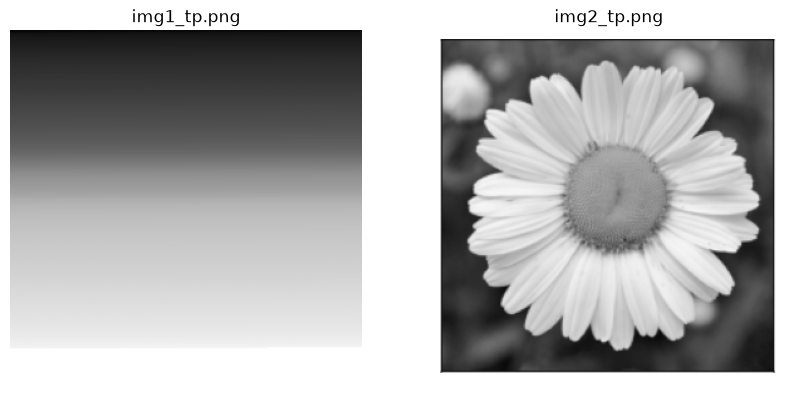

In [10]:
import matplotlib.pyplot as plt
import cv2 as cv
import math

n = len(imagenes)

# 2 columnas
columnas = 2
filas = math.ceil(n / columnas)

fig = plt.figure(figsize=(10, 5 * filas))

for i, (nombre, img) in enumerate(imagenes.items()):

    # BGR -> RGB
    #img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    print(f"{nombre} - Tamaño: {img.shape}")

    # Subplot: filas x columnas
    ax = plt.subplot(filas, columnas, i + 1)

    ax.imshow(img,cmap="gray")
    ax.set_title(nombre)
    ax.axis("off")

plt.tight_layout

Armo histogramas con 16 bins

img1_tp.png - Tamaño: (288, 287)
img2_tp.png - Tamaño: (288, 287)


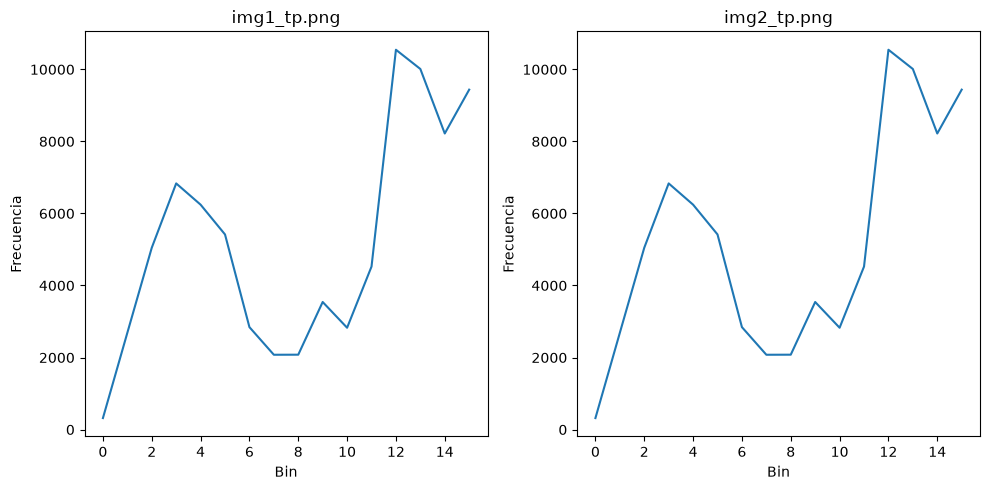

In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt

n = len(imagenes)

# 2 columnas
columnas = 2
filas = math.ceil(n / columnas)

fig = plt.figure(figsize=(10, 5 * filas))

for i, (nombre, img) in enumerate(imagenes.items()):

    print(f"{nombre} - Tamaño: {img.shape}")

    # Subplot: filas x columnas
    ax = plt.subplot(filas, columnas, i + 1)

    # Histograma con 16 bins
    hist1, bins1 = np.histogram(
        img.ravel(),
        bins=16,
        range=(0, 256)
    )

    ax.plot(hist1)

    ax.set_title(nombre)
    ax.set_xlabel("Bin")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Los histogramas obtenidos muestran una distribución de niveles de gris muy similar para ambas imágenes. Se observa una mayor concentración de píxeles en los niveles de intensidad bajos y altos, mientras que existe una menor frecuencia en los niveles intermedios. Esto indica que las imágenes presentan una distribución bimodal de intensidades, con presencia predominante de regiones oscuras y claras. A partir de los histogramas, se puede concluir que ambas imágenes poseen características de distribución de intensidad similares.

Si voy a intentar clasificar una imagen, principlamente miraría en el histograma cómo se distribuyen los niveles de gris (en este caso 16 bins)
Observaría:

Concentración en valores bajos → predominan zonas oscuras.

Concentración en valores altos → predominan zonas claras.

Distribución alrededor del centro → predominan grises medios.

Histograma muy extendido → mayor variabilidad/contraste.

Picos pronunciados → determinados rangos de intensidad aparecen con mucha frecuencia.

Histograma relativamente plano → los niveles de gris están más distribuidos.

Para clasificación, el modelo podría aprender algo como:

"Las imágenes de la clase A tienden a tener mayor cantidad de píxeles en los bins bajos, mientras que las de la clase B presentan mayor concentración en los bins medios/altos."